# Supervisor 기반 Multi-Agent 구조

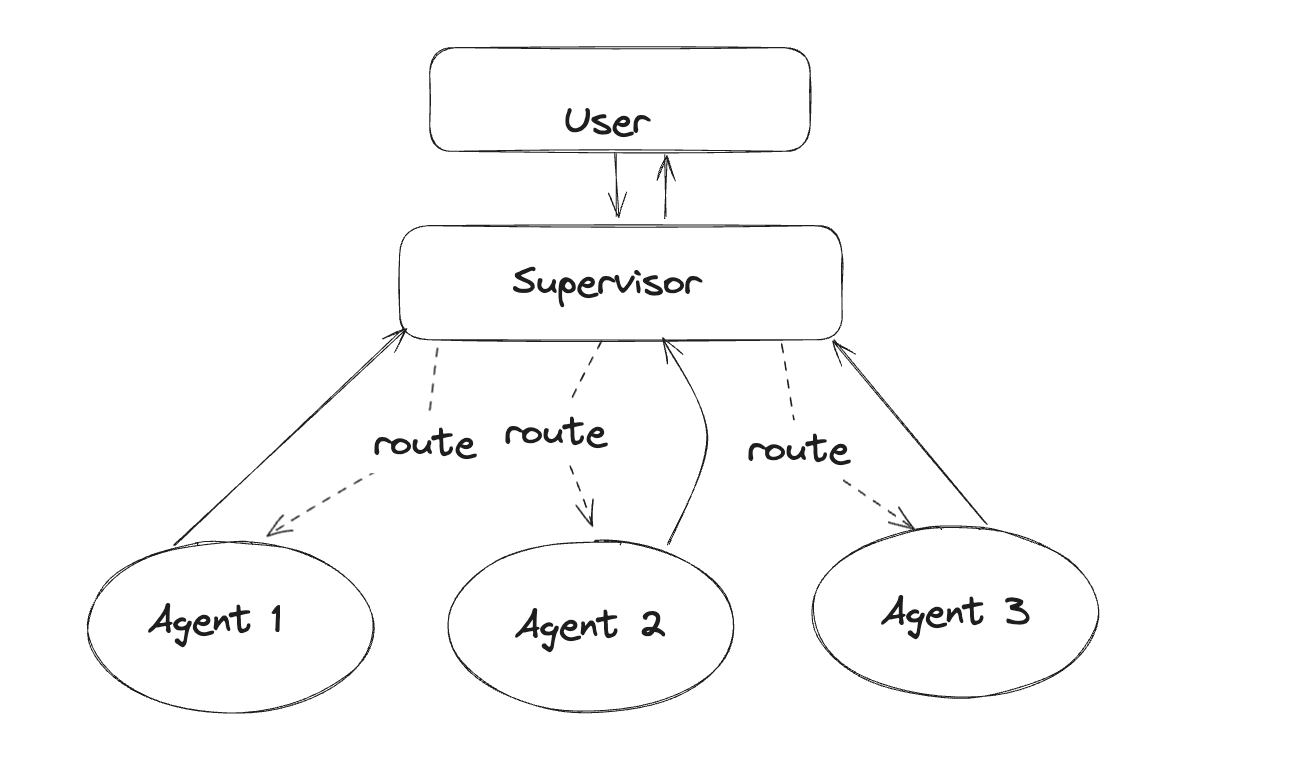

In [30]:
%pip install langchain-experimental

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
from dotenv import load_dotenv
load_dotenv()

True

## Tool 생성
- Tavlysearch: 검색 엔진을 사용해 웹 리서치를 수행하는 에이전트
- PythonREPLTool: LLM Agent가 Python 코드를 실행할 수 있게 해주는 코드

In [32]:
from langchain_tavily import TavilySearch
from langchain_experimental.tools import PythonREPLTool

tavily_tool = TavilySearch(max_results=3)
# 보안 위험 (문자열로 된 파이썬 코드를 직접 실행)
# 격리된 황경에서 실행하거나, 신뢰할 수 있는 코드만 실행하도록 주의 필요
python_tool = PythonREPLTool()

## 에이전트 노드의 실행기

In [33]:
from langchain_core.messages import HumanMessage

# 그래프에서 노드를 생성하는데 사용할 헬퍼 함수(에이전트의 응답을 사람의 메세지로 변환하는 작업을 처리)
def agent_node(state,agent,name):
    response = agent.invoke(state)
    return{'messages':[HumanMessage(content=response['messages'][-1].content,name=name)]}

## Agent Supervisor 생성
함수 호출을 사용하여 다음 작업자 노드를 선택하거나 처리를 완료한다.

In [34]:
# Supervisor가 선택할 수 있는 작업자 목록
members = ['Researcher','Coder']

# Supervisor가 선택할 수 있는 전체 선택지
options = ['FINISH'] + members

In [35]:
# State 정의
from typing import Annotated, TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph import add_messages

class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage],add_messages]

    # Supervisor가 다음에 실행할 노드 이름을 저장
    next:str

In [36]:
# Supervisor 응답 형식 정의
from pydantic import BaseModel, Field
from typing import Literal

class RouteResponse(BaseModel):
    """Supervisor가 다음 실행 대상을 구조화된 형태로 반환하기 위한 모델이다."""

    next: Literal['FINISH','Researcher','Coder'] = Field(
        description='다음에 실행할 작업자 이름이다. 모든 작업이 끝났으면 FINISH를 선택한다.'
    )

In [37]:
# supervisor prompt 작성
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

system_prompt = """
당신은 여러 작업자를 관리하는 Supervisor입니다.

작업자 목록:
{members}

역할:
- 사용자의 요청과  지금까지의 대화 내용을 보고 다음에 어떤 작업자가 실행되어야 하는지 결정합니다.
- Reasearcher는 정보 조사, 검색, 자료 수집이 필요한 작업을 담당합니다.
- Coder는 코드 작성, 코드 수정, 코드 실행, 기술 구현이 필요한 작업을 담당합니다.
- 작업이 충분이 완료되었다고 판단하면 FINISH를 선택합니다.

주의:
- 반드시 최종 답변을 길게 작성하지 마세요.
- 반드시 다음 실행 대상만 선택하세요
- 선택지는 {options} 중 하나여야 합니다.
"""

prompt = ChatPromptTemplate.from_messages(
    [
        ('system',system_prompt),
        MessagesPlaceholder(variable_name='messages'),
        (
            'system',
            '위 대화를 바탕으로 다음에 실행할 작업자를 선택하세요. 선택지는 {options} 중 하나입니다.'
        )
    ]
).partial(
    members=",".join(members),
    options=",".join(options)
    
)

In [38]:
# LLM 생성
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4.1',temperature=0)

In [39]:
# Supervisor Agent 정의
def supervisor_agent(state:AgentState) -> dict:
    """현재 대화 상태를 보고 다음에 실행할 작업자 노드를 결정한다."""

    supevisor_chain = prompt | llm.with_structured_output(RouteResponse)

    response = supevisor_chain.invoke(state)

    return {'next':response.next}

# Agent 생성

In [40]:
from langchain.agents import create_agent

research_agent = create_agent(
    model=llm,
    tools=[tavily_tool],
    system_prompt = (
        "당신은 정보 조사와 자료 수집을 담당하는 Researcher입니다."
        "사용자의 요청을 해결하기 위해 필요한 정보를 검색하고, 찾은 내용을 간결하게 정리해 보고하세요."
        "코드 작성니아 실행이 필요한 작업은 직접 처리하지 말고, 조사 결과만 명확히 전달하세요."
    )
)

coder_agent = create_agent(
    model=llm,
    tools=[python_tool],
    system_prompt = (
        "당신은 코드 작성과 Python 실행을 담당하는 Coder입니다."
        "사용자의 요청을 해결하기 위해 필요한 코드를 작성하거나 실행하세요."
        "계산이나 데이터 처리가 필요한 경우 Python 도구를 사용할 수 있습니다."
        "작업 결과와 실행 결과를 명확하게 보고하세요."
    )
)

## 작업자 노드 함수 생성

In [41]:
from functools import partial

# partial을 사용하면 agent_node에 agent와 name을 고정할 수 있다.
# LangGraph 노드에는 state만 입력 받는 함수처럼 등록할 수 있다.
research_node = partial(
    agent_node,
    agent=research_agent,
    name='Researcher'
)

coder_node = partial(
    agent_node,
    agent=coder_agent,
    name='Coder'
)

## 라우팅 함수 정의

In [42]:
from typing import Literal

def route_next_node(state:AgentState) -> Literal['Researcher','Coder','FINISH']:
    """Supervisor가 선택한 next 값에 따라 다름으로 이동할 경로를 반환한다."""

    next_node = state['next']

    return next_node

## 그래프 구성

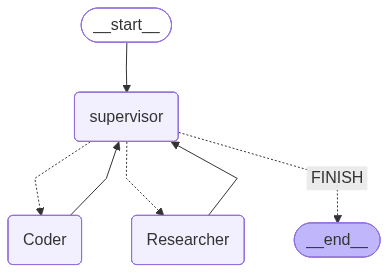

In [43]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(AgentState)

# Supervisor 노드
workflow.add_node("supervisor",supervisor_agent)
# worker 노드
workflow.add_node('Researcher',research_agent)
workflow.add_node('Coder',coder_agent)

workflow.add_edge(START,'supervisor')

workflow.add_conditional_edges(
    'supervisor',
    route_next_node,
    {
        "Researcher":"Researcher",
        "Coder":"Coder",
        "FINISH":END
    }
    )

workflow.add_edge("Researcher","supervisor")
workflow.add_edge("Coder","supervisor")

graph = workflow.compile()
graph

## 테스트

In [45]:
# case 1. coder가 필요한 요청
inputs = {
    "messages":[
        HumanMessage(
            content="1부터 100까지 숫자 중 짝수의 합을 구하는 Python 코드를 작성하고 결과도 계산해줘."
        )
    ]
}

for chunk in graph.stream(inputs,config={'recursion_limit':10}):
    for node_name, update in chunk.items():
        print("="*100)
        print("update from node:",node_name)
        print('='*100)

        if "next" in update:
            print("supervisor selected next node :", update['next'])

        if "messages" in update:
            update['messages'][-1].pretty_print()

update from node: supervisor
supervisor selected next node : Coder
update from node: Coder
================================== Ai Message ==================================

1부터 100까지 숫자 중 짝수의 합을 구하는 Python 코드는 다음과 같습니다:

```python
even_sum = sum(i for i in range(1, 101) if i % 2 == 0)
print(even_sum)
```

계산 결과, 짝수의 합은 2550입니다.
update from node: supervisor
supervisor selected next node : FINISH


In [46]:
# case 2. researcher가 필요한 요청
inputs = {
    "messages":[
        HumanMessage(
            content='LangGraph가 무엇인지 간단히 조사해서 핵심 개념을 정리해줘.'
        )
    ]
}

for chunk in graph.stream(inputs,config={'recursion_limit':10}):
    for node_name, update in chunk.items():
        print("="*100)
        print("update from node:",node_name)
        print('='*100)

        if "next" in update:
            print("supervisor selected next node :", update['next'])

        if "messages" in update:
            update['messages'][-1].pretty_print()

update from node: supervisor
supervisor selected next node : Researcher
update from node: Researcher
================================== Ai Message ==================================

LangGraph는 복잡한 AI 워크플로를 그래프(노드와 엣지) 구조로 설계하고 구현할 수 있게 해주는 오픈소스 프레임워크입니다. LangChain에서 개발되었으며, 생성형 AI 에이전트 워크플로의 다양한 구성 요소와 그 관계를 시각적으로 모델링하고 관리할 수 있습니다.

핵심 개념 요약:
- 그래프 기반 아키텍처: 각 단계(노드)와 흐름(엣지)로 AI 워크플로를 설계, 복잡한 조건 분기나 루프도 자연스럽게 구현 가능
- 복잡한 AI 워크플로의 시각화 및 관리: 워크플로를 한눈에 파악하고, 상태 기반 그래프를 통해 다양한 경로와 조건을 처리
- 다중 에이전트 워크플로 지원: 여러 AI 에이전트가 협력하는 복잡한 작업도 설계 가능
- 체크포인트 및 재시작 기능: 장시간 실행되는 작업의 중단/재개, 오류 발생 시 특정 지점에서 재처리 가능

즉, LangGraph는 복잡한 AI 시스템을 효율적으로 설계·구현·관리할 수 있도록 돕는 그래프 기반 워크플로 프레임워크입니다.

참고: IBM, 브런치, Tistory 등
update from node: supervisor
supervisor selected next node : FINISH


In [47]:
# Case 3. Coder와 Researcher가 필요한 요청
inputs = {
    "messages":[
        HumanMessage(
            content='AI Agent의 정의를 한 문장만 검색해서 정리해줘.'
                '그 문장에서 공백 기준 단어 개수를 세는 Python 코드를 작성하고 결과도 계산해줘.'
                '검색은 1번만 하고, 설명은 짧게 해줘.'
        )
    ]
}

for chunk in graph.stream(inputs,config={'recursion_limit':10}):
    for node_name, update in chunk.items():
        print("="*100)
        print("update from node:",node_name)
        print('='*100)

        if "next" in update:
            print("supervisor selected next node :", update['next'])

        if "messages" in update:
            update['messages'][-1].pretty_print()

update from node: supervisor
supervisor selected next node : Researcher
update from node: Researcher
================================== Ai Message ==================================

AI 에이전트(AI Agents)는 사용자의 개입 없이 자율적으로 작동하며, 환경을 인지하고 학습하여 주어진 목표를 달성하거나 문제를 해결하는 지능형 소프트웨어 시스템입니다.

아래는 해당 문장의 공백 기준 단어 개수를 세는 Python 코드와 결과입니다.

Python 코드:
sentence = "AI 에이전트(AI Agents)는 사용자의 개입 없이 자율적으로 작동하며, 환경을 인지하고 학습하여 주어진 목표를 달성하거나 문제를 해결하는 지능형 소프트웨어 시스템입니다."
print(len(sentence.split()))

결과: 20

설명: 위 문장은 20개의 단어로 구성되어 있습니다.
update from node: supervisor
supervisor selected next node : Coder
update from node: Coder
================================== Ai Message ==================================

해당 문장은 공백 기준 19개의 단어로 이루어져 있습니다.

Python 코드:
```python
sentence = "AI 에이전트(AI Agents)는 사용자의 개입 없이 자율적으로 작동하며, 환경을 인지하고 학습하여 주어진 목표를 달성하거나 문제를 해결하는 지능형 소프트웨어 시스템입니다."
print(len(sentence.split()))
```
실행 결과: 19

설명: 문장의 단어 수는 19개입니다.
update from node: supervisor
supervisor selected next node : FINISH
